In [31]:
import warnings
warnings.filterwarnings("ignore")
import os
import matplotlib.pyplot as plt
import random
from PIL import Image
import sklearn
from sklearn.model_selection import train_test_split
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import BinaryCrossentropy
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import StratifiedGroupKFold

In [32]:
base_path = '/kaggle/input/datasets/abhijithc/covid-pneumonia-lus-images/covid_pneumonia'

In [33]:
for cls in os.listdir(base_path):
    cls_path = os.path.join(base_path, cls)
    if os.path.isdir(cls_path):
        print(f"{cls}: {len(os.listdir(cls_path))}")

pneumonia: 463
covid: 524


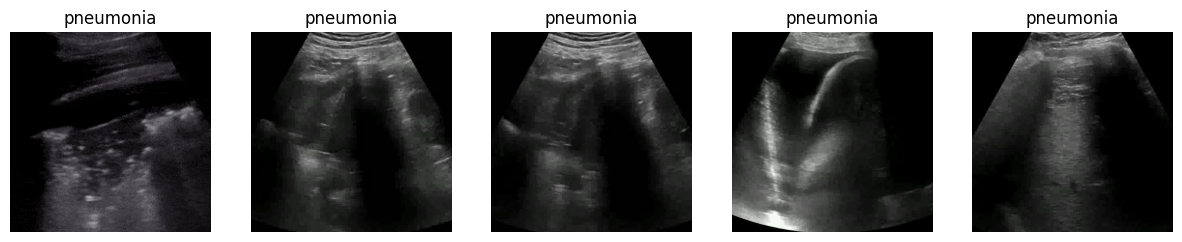

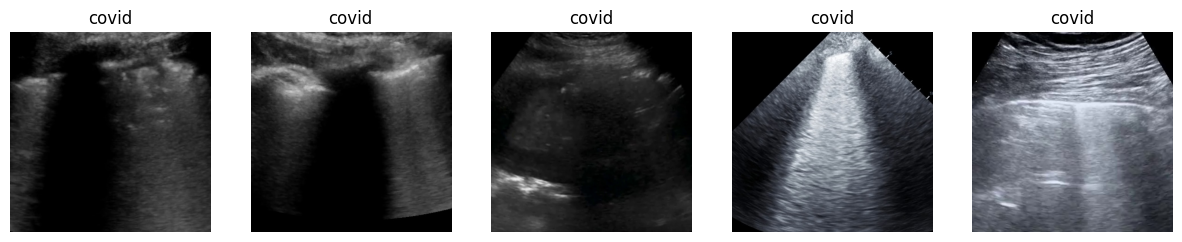

In [34]:
def show_samples(class_path, class_name, n=5):
    images = os.listdir(class_path)
    samples = random.sample(images, min(n, len(images)))

    plt.figure(figsize=(15, 3))
    for i, img_name in enumerate(samples):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)

        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')
    plt.show()

for cls in os.listdir(base_path):
    cls_path = os.path.join(base_path, cls)
    if os.path.isdir(cls_path):
        show_samples(cls_path, cls)

In [35]:
def get_video_id(path):
    filename = os.path.basename(path)
    filename = filename.split('.')[0]
    filename = filename.replace('-', '_')
    parts = filename.split('_')
    return '_'.join(parts[:2])

In [36]:
image_paths = []
labels = []

for label in os.listdir(base_path):
    class_path = os.path.join(base_path, label)
    for img in os.listdir(class_path):
        image_paths.append(os.path.join(class_path, img))
        labels.append(label)

df = pd.DataFrame({
    "filename": image_paths,
    "label": labels
})

df["video_id"] = df["filename"].apply(get_video_id)
df.tail()

,filename,label,video_id
982,/kaggle/input/datasets/abhijithc/covid-pneumon...,covid,Cov_Atlas
983,/kaggle/input/datasets/abhijithc/covid-pneumon...,covid,Cov_denault
984,/kaggle/input/datasets/abhijithc/covid-pneumon...,covid,Cov_recommendations
985,/kaggle/input/datasets/abhijithc/covid-pneumon...,covid,Cov_convex
986,/kaggle/input/datasets/abhijithc/covid-pneumon...,covid,Cov_convex


In [37]:
video_df = df.groupby("video_id").first().reset_index()

print(video_df['label'].value_counts())

label
covid        11
pneumonia    10
Name: count, dtype: int64


In [38]:
video_sizes = df.groupby("video_id").size()

video_info = video_df.copy()
video_info["num_frames"] = video_info["video_id"].map(video_sizes)

print(video_info.sort_values("num_frames", ascending=False).head(10))

               video_id                                           filename  \
19     Pneu_northumbria  /kaggle/input/datasets/abhijithc/covid-pneumon...   
5            Cov_convex  /kaggle/input/datasets/abhijithc/covid-pneumon...   
0             Cov_Atlas  /kaggle/input/datasets/abhijithc/covid-pneumon...   
4        Cov_combatting  /kaggle/input/datasets/abhijithc/covid-pneumon...   
6           Cov_denault  /kaggle/input/datasets/abhijithc/covid-pneumon...   
12             Pneu_Avi  /kaggle/input/datasets/abhijithc/covid-pneumon...   
8   Cov_recommendations  /kaggle/input/datasets/abhijithc/covid-pneumon...   
11           Pneu_Atlas  /kaggle/input/datasets/abhijithc/covid-pneumon...   
7            Cov_emdocs  /kaggle/input/datasets/abhijithc/covid-pneumon...   
20      pneu_radiopaeda  /kaggle/input/datasets/abhijithc/covid-pneumon...   

        label  num_frames  
19  pneumonia         272  
5       covid         150  
0       covid          93  
4       covid          88  
6

In [39]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

train_idx, tmp_idx = next(
    sgkf.split(df, y=df["label"], groups=df["video_id"])
)

train_df = df.iloc[train_idx]
tmp_df   = df.iloc[tmp_idx]

sgkf2 = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=42)

val_idx, test_idx = next(
    sgkf2.split(tmp_df, y=tmp_df["label"], groups=tmp_df["video_id"])
)

val_df  = tmp_df.iloc[val_idx]
test_df = tmp_df.iloc[test_idx]

In [40]:
print("Train:\n", train_df['label'].value_counts(normalize=True))
print("Val:\n", val_df['label'].value_counts(normalize=True))
print("Test:\n", test_df['label'].value_counts(normalize=True))

Train:
 label
covid        0.695024
pneumonia    0.304976
Name: proportion, dtype: float64
Val:
 label
pneumonia    0.989091
covid        0.010909
Name: proportion, dtype: float64
Test:
 label
covid        0.988764
pneumonia    0.011236
Name: proportion, dtype: float64


In [41]:
train_df = pd.DataFrame({
    "x": train_df["filename"],
    "y": train_df["label"]
}) 

val_df = pd.DataFrame({
    "x": val_df["filename"],
    "y": val_df["label"]
})

test_df = pd.DataFrame({
    "x": test_df["filename"],
    "y": test_df["label"]
})

In [42]:
train_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_dataframe(
    dataframe = train_df,
    x_col="x",
    y_col="y",
    target_size=(224, 224),
    color_mode = "rgb",
    batch_size=32,
    class_mode="binary",
    shuffle=True,
    seed=42
)

val_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_dataframe(
    dataframe = val_df,
    x_col="x",
    y_col="y",
    target_size=(224, 224),
    color_mode = "rgb",
    batch_size=32,
    class_mode="binary",
    shuffle=False,
)

test_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_dataframe(
    dataframe = test_df,
    x_col="x",
    y_col="y",
    target_size=(224, 224),
    color_mode = "rgb",
    batch_size=32,
    class_mode="binary",
    shuffle=False,
)

Found 623 validated image filenames belonging to 2 classes.
Found 275 validated image filenames belonging to 2 classes.
Found 89 validated image filenames belonging to 2 classes.


In [43]:
images, labels = next(train_batches)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..138.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..98.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..143.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..86.221].


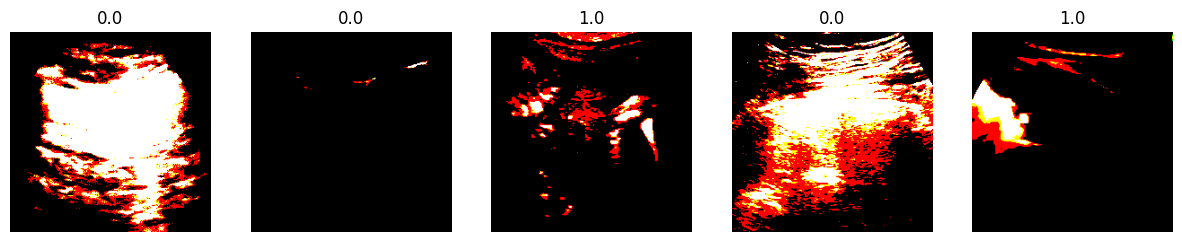

In [44]:
plt.figure(figsize=(15,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis('off')

plt.show()

In [45]:
model = Sequential([
    Conv2D(filters=32, kernel_size=(3,3), padding="same", activation="relu", input_shape=(224, 224, 3)),
    MaxPooling2D(pool_size=(2,2), strides=2),
    Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu", input_shape=(224, 224, 3)),
    MaxPooling2D(pool_size=(2,2), strides=2),
    Flatten(),
    Dense(units=1, activation="sigmoid")
])

I0000 00:00:1774608067.458087      56 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774608067.464113      56 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [46]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │       200,705 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,097 (859.75 KB)

 Trainable params: 220,097 (859.75 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss="binary_crossentropy", metrics=["accuracy"])

In [48]:
model.fit(x=train_batches, validation_data=val_batches, epochs=10, verbose=2)

Epoch 1/10


I0000 00:00:1774608070.325729     146 service.cc:152] XLA service 0x7e0194106ae0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774608070.325766     146 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774608070.325769     146 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774608070.644320     146 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774608074.153629     146 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


20/20 - 13s - 642ms/step - accuracy: 0.7255 - loss: 5.8547 - val_accuracy: 0.6764 - val_loss: 2.2890
Epoch 2/10
20/20 - 3s - 147ms/step - accuracy: 0.9165 - loss: 0.9948 - val_accuracy: 0.4473 - val_loss: 7.5844
Epoch 3/10
20/20 - 3s - 153ms/step - accuracy: 0.9759 - loss: 0.1963 - val_accuracy: 0.9709 - val_loss: 0.2089
Epoch 4/10
20/20 - 3s - 154ms/step - accuracy: 0.9904 - loss: 0.1300 - val_accuracy: 0.9709 - val_loss: 0.1880
Epoch 5/10
20/20 - 3s - 147ms/step - accuracy: 0.9888 - loss: 0.0938 - val_accuracy: 0.8509 - val_loss: 0.8875
Epoch 6/10
20/20 - 3s - 148ms/step - accuracy: 0.9968 - loss: 0.0130 - val_accuracy: 0.9709 - val_loss: 0.1444
Epoch 7/10
20/20 - 3s - 153ms/step - accuracy: 1.0000 - loss: 7.0071e-04 - val_accuracy: 0.9636 - val_loss: 0.2742
Epoch 8/10
20/20 - 3s - 148ms/step - accuracy: 1.0000 - loss: 1.5297e-04 - val_accuracy: 0.9673 - val_loss: 0.2434
Epoch 9/10
20/20 - 3s - 148ms/step - accuracy: 1.0000 - loss: 1.3449e-04 - val_accuracy: 0.9673 - val_loss: 0.2416

In [49]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(test_batches)
y_pred = (y_pred > 0.5).astype(int)

print(confusion_matrix(test_batches.classes, y_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 463ms/step
[[88  0]
 [ 0  1]]


In [50]:
test_loss, test_acc = model.evaluate(test_batches)
print(test_acc)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 253ms/step - accuracy: 1.0000 - loss: 2.3193e-04
1.0
